# A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles
This is the code for the paper entitled "**A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles**" published in **IEEE International Conference on Communications (IEEE ICC)**, doi=[10.1109/ICC45855.2022.9838780](https://ieeexplore.ieee.org/document/9838780).    
Authors: Li Yang (lyang339@uwo.ca) and Abdallah Shami (Abdallah.Shami@uwo.ca)  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

**Notebook 2: CNN Model Development**  
Aims:  
&nbsp; 1): Generate training and test images  
&nbsp; 2): Construct CNN models (a CNN model by own, Xception, VGG16, VGG19, Resnet, Inception, InceptionResnet)  
&nbsp; 3): Tune the hyperparameters of CNN models (hyperparameter optimization)  

In [1]:
#!unzip -q ./train_224.zip -d /fast_dataset

In [2]:
!ls -F /fast_dataset

test_224/  train_224/


## Import libraries

In [3]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [4]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Flatten,GlobalAveragePooling2D,Input,Conv2D,MaxPooling2D,Dropout
from keras.models import Model,load_model,Sequential
from keras.applications.xception import  Xception
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.resnet50 import  ResNet50
from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from keras.applications.mobilenet import MobileNet
import keras.callbacks as kcallbacks
import keras
from keras.preprocessing.image import load_img,img_to_array
import math
import random
from keras.utils import plot_model
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import numpy as np
from PIL import Image
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

2026-05-21 02:51:45.887388: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-21 02:51:45.887544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-21 02:51:45.907045: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-21 02:51:45.971745: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Generate Training and Test Images

In [5]:
import tensorflow as tf
print("¿GPU Activa?:", tf.config.list_physical_devices('GPU'))

¿GPU Activa?: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-21 02:51:55.980889: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 02:51:56.059305: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 02:51:56.059355: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [6]:
#generate training and test images
TARGET_SIZE=(224,224)
INPUT_SIZE=(224,224,3)
BATCHSIZE=64	#could try 128 or 32

#Normalization
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/fast_dataset/train_224',
        target_size=TARGET_SIZE,
        batch_size=BATCHSIZE,
        class_mode='categorical',
        classes=['0', '1', '2', '3', '4'])
validation_generator = test_datagen.flow_from_directory(
        '/fast_dataset/test_224',
        target_size=TARGET_SIZE,
        batch_size=BATCHSIZE,
        class_mode='categorical',
        classes=['0', '1', '2', '3', '4'])

Found 37057 images belonging to 5 classes.
Found 9267 images belonging to 5 classes.


### Define the image plotting functions

In [7]:
#plot the figures
class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = {'batch':[], 'epoch':[]}
        self.accuracy = {'batch':[], 'epoch':[]}
        self.val_loss = {'batch':[], 'epoch':[]}
        self.val_acc = {'batch':[], 'epoch':[]}
    def on_batch_end(self, batch, logs={}):
        self.losses['batch'].append(logs.get('loss'))
        self.accuracy['batch'].append(logs.get('acc'))
        self.val_loss['batch'].append(logs.get('val_loss'))
        self.val_acc['batch'].append(logs.get('val_acc'))
    def on_epoch_end(self, batch, logs={}):
        self.losses['epoch'].append(logs.get('loss'))
        self.accuracy['epoch'].append(logs.get('acc'))
        self.val_loss['epoch'].append(logs.get('val_loss'))
        self.val_acc['epoch'].append(logs.get('val_acc'))
    def loss_plot(self, loss_type):
        iters = range(len(self.losses[loss_type]))
        plt.figure()
        plt.plot(iters, self.losses[loss_type], 'g', label='train loss')
        if loss_type == 'epoch':
            # acc
            plt.plot(iters, self.accuracy[loss_type], 'r', label='train acc')
            # loss
            plt.plot(iters, self.losses[loss_type], 'g', label='train loss')
            # val_acc
            plt.plot(iters, self.val_acc[loss_type], 'b', label='val acc')
            # val_loss
            plt.plot(iters, self.val_loss[loss_type], 'k', label='val loss')
        plt.grid(True)
        plt.xlabel(loss_type)
        plt.ylabel('acc-loss')
        plt.legend(loc="upper right")
        plt.show()

In [8]:
history_this= LossHistory()

# Construct CNN models

### Model 1: a CNN model by own (baseline)

In [9]:
def cnn_by_own(input_shape,num_class,epochs,savepath='./model_own.h5'):
    model = Sequential()
    model.add(Conv2D(64,(3,3),strides=(1,1),input_shape=input_shape,padding='same',activation='relu',kernel_initializer='glorot_uniform'))
    model.add(Conv2D(64,(3,3),strides=(1,1),padding='same',activation='relu',kernel_initializer='glorot_uniform'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Conv2D(128,(3,3),strides=(1,1),padding='same',activation='relu',kernel_initializer='glorot_uniform'))
    model.add(Conv2D(128,(3,3),strides=(1,1),padding='same',activation='relu',kernel_initializer='glorot_uniform'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Conv2D(256,(3,3),strides=(1,1),padding='same',activation='relu',kernel_initializer='glorot_uniform'))
    model.add(Conv2D(256,(3,3),strides=(1,1),padding='same',activation='relu',kernel_initializer='glorot_uniform'))
    model.add(Conv2D(256,(3,3),strides=(1,1),padding='same',activation='relu',kernel_initializer='glorot_uniform'))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256,activation='relu'))
    model.add(Dropout(rate=0.5))
    model.add(Dense(num_class,activation='softmax'))
    model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
    #train model
    earlyStopping=kcallbacks.EarlyStopping(monitor='val_accuracy', patience=3, verbose=1, mode='max')
    saveBestModel = kcallbacks.ModelCheckpoint(filepath=savepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
    hist=model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        callbacks=[earlyStopping,saveBestModel,history_this],
    )

2026-05-20 20:57:29.640320: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 20:57:29.640404: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 20:57:29.640436: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 20:57:29.819195: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 20:57:29.819252: I external/local_xla/xla/stream_executor

Epoch 1/20


2026-05-20 20:57:31.837226: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-05-20 20:57:39.682898: I external/local_xla/xla/service/service.cc:168] XLA service 0x7836c9c49ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-20 20:57:39.682955: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-05-20 20:57:39.689541: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779310659.770821    4777 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


580/580 [==============================] - ETA: 0s - loss: 0.1890 - accuracy: 0.9422
Epoch 1: val_accuracy improved from -inf to 0.99342, saving model to ./model_own.h5


/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


580/580 [==============================] - 241s 375ms/step - loss: 0.1890 - accuracy: 0.9422 - val_loss: 0.0218 - val_accuracy: 0.9934
Epoch 2/20
580/580 [==============================] - ETA: 0s - loss: 0.0221 - accuracy: 0.9944
Epoch 2: val_accuracy improved from 0.99342 to 0.99665, saving model to ./model_own.h5
580/580 [==============================] - 207s 358ms/step - loss: 0.0221 - accuracy: 0.9944 - val_loss: 0.0106 - val_accuracy: 0.9967
Epoch 3/20
580/580 [==============================] - ETA: 0s - loss: 0.0154 - accuracy: 0.9960
Epoch 3: val_accuracy improved from 0.99665 to 0.99817, saving model to ./model_own.h5
580/580 [==============================] - 208s 358ms/step - loss: 0.0154 - accuracy: 0.9960 - val_loss: 0.0068 - val_accuracy: 0.9982
Epoch 4/20
580/580 [==============================] - ETA: 0s - loss: 0.0149 - accuracy: 0.9957
Epoch 4: val_accuracy did not improve from 0.99817
580/580 [==============================] - 208s 359ms/step - loss: 0.0149 - accura

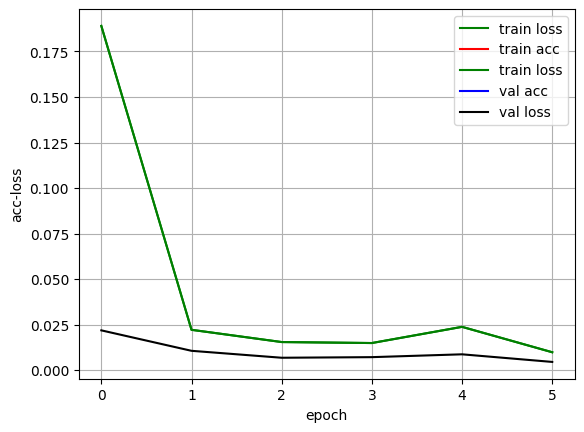

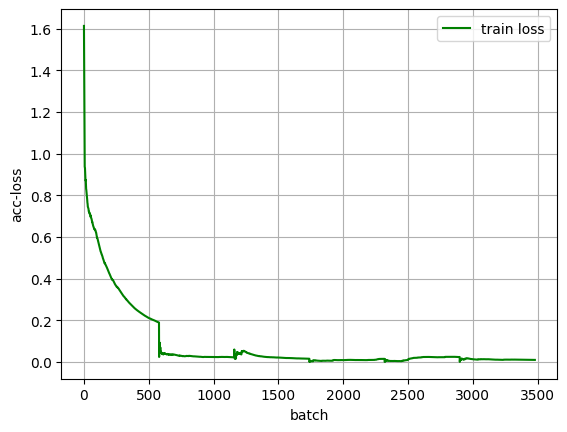

In [10]:
cnn_by_own(input_shape=INPUT_SIZE,num_class=5,epochs=20)
history_this.loss_plot('epoch')
history_this.loss_plot('batch')
plt.show()

Validation accuracy of a CNN by own: 99.884%

### Model 2: Xception

In [10]:
def xception( num_class, epochs,savepath='./xception.h5',history=history_this,input_shape=INPUT_SIZE):
    model_fine_tune = Xception(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in model_fine_tune.layers[:121]:		#could be tuned to be 50, 100, or 131
        layer.trainable = False
    for layer in model_fine_tune.layers[121:]:
        layer.trainable = True
    model = GlobalAveragePooling2D()(model_fine_tune.output)
    model=Dense(units=256,activation='relu')(model)
    model=Dropout(0.5)(model)
    model = Dense(num_class, activation='softmax')(model)
    model = Model(model_fine_tune.input, model, name='xception')
    opt = keras.optimizers.Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    #train model
    earlyStopping = kcallbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, verbose=1, mode='max')	#patience could be tuned by 2 and 3
    saveBestModel = kcallbacks.ModelCheckpoint(
        filepath=savepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max')
    hist = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        #use_multiprocessing=True,
        callbacks=[earlyStopping, saveBestModel, history],
    )


Epoch 1/20
580/580 [==============================] - ETA: 0s - loss: 0.0375 - accuracy: 0.9879
Epoch 1: val_accuracy improved from -inf to 0.96568, saving model to ./xception.h5
580/580 [==============================] - 119s 186ms/step - loss: 0.0375 - accuracy: 0.9879 - val_loss: 0.0950 - val_accuracy: 0.9657
Epoch 2/20
580/580 [==============================] - ETA: 0s - loss: 0.0113 - accuracy: 0.9969
Epoch 2: val_accuracy improved from 0.96568 to 0.99773, saving model to ./xception.h5
580/580 [==============================] - 104s 179ms/step - loss: 0.0113 - accuracy: 0.9969 - val_loss: 0.0070 - val_accuracy: 0.9977
Epoch 3/20
580/580 [==============================] - ETA: 0s - loss: 0.0080 - accuracy: 0.9981
Epoch 3: val_accuracy improved from 0.99773 to 0.99817, saving model to ./xception.h5
580/580 [==============================] - 104s 179ms/step - loss: 0.0080 - accuracy: 0.9981 - val_loss: 0.0063 - val_accuracy: 0.9982
Epoch 4/20
580/580 [==============================] 

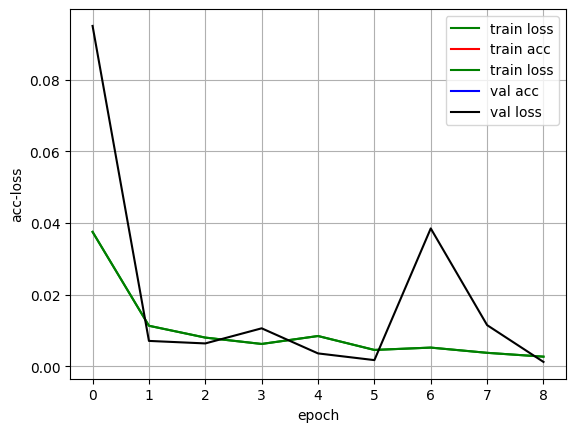

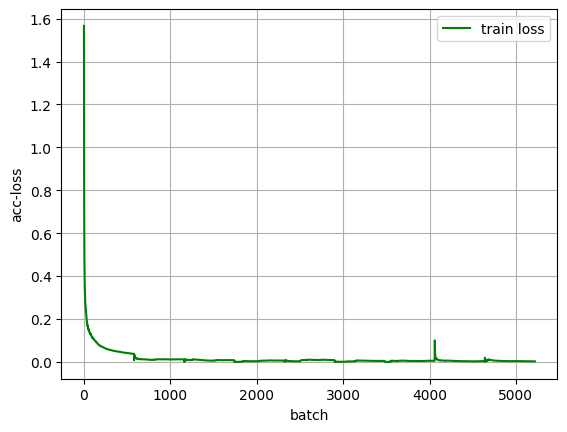

In [12]:
#default only 50, tf36cnn 99
xception(num_class=5,epochs=20)
history_this.loss_plot('epoch')
history_this.loss_plot('batch')
plt.show()

Validation accuracy of Xception: 100.0%

### Model 3: VGG16

In [11]:
def vgg16( num_class, epochs,savepath='./VGG16.h5',history=history_this,input_shape=INPUT_SIZE):
    model_fine_tune = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in model_fine_tune.layers[:15]:	#the number of frozen layers for transfer learning, have tuned from 5-18
        layer.trainable = False
    for layer in model_fine_tune.layers[15:]:
        layer.trainable = True
    model = GlobalAveragePooling2D()(model_fine_tune.output) #GlobalAveragePooling2D layer to convert the features to a single 1280-element vector per image
    model=Dense(units=256,activation='relu')(model)
    model=Dropout(0.5)(model)
    model = Dense(num_class, activation='softmax')(model)
    model = Model(model_fine_tune.input, model, name='vgg')
    opt = keras.optimizers.Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=1e-08)	#tuned learning rate to be 0.001
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])	#set the loss function to be binary crossentropy
    #train model
    earlyStopping = kcallbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, verbose=1, mode='max')	#set early stop patience to save training time
    saveBestModel = kcallbacks.ModelCheckpoint(
        filepath=savepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max')
    hist = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        #use_multiprocessing=True,
        #workers=2,
        callbacks=[earlyStopping, saveBestModel, history],
    )


Epoch 1/20
580/580 [==============================] - ETA: 0s - loss: 0.3108 - accuracy: 0.9620
Epoch 1: val_accuracy improved from -inf to 0.97917, saving model to ./VGG16.h5
580/580 [==============================] - 115s 192ms/step - loss: 0.3108 - accuracy: 0.9620 - val_loss: 0.0732 - val_accuracy: 0.9792
Epoch 2/20
580/580 [==============================] - ETA: 0s - loss: 0.0275 - accuracy: 0.9942
Epoch 2: val_accuracy improved from 0.97917 to 0.99622, saving model to ./VGG16.h5
580/580 [==============================] - 110s 189ms/step - loss: 0.0275 - accuracy: 0.9942 - val_loss: 0.0103 - val_accuracy: 0.9962
Epoch 3/20
580/580 [==============================] - ETA: 0s - loss: 0.0177 - accuracy: 0.9968
Epoch 3: val_accuracy improved from 0.99622 to 0.99849, saving model to ./VGG16.h5
580/580 [==============================] - 110s 190ms/step - loss: 0.0177 - accuracy: 0.9968 - val_loss: 0.0045 - val_accuracy: 0.9985
Epoch 4/20
580/580 [==============================] - ETA: 0s

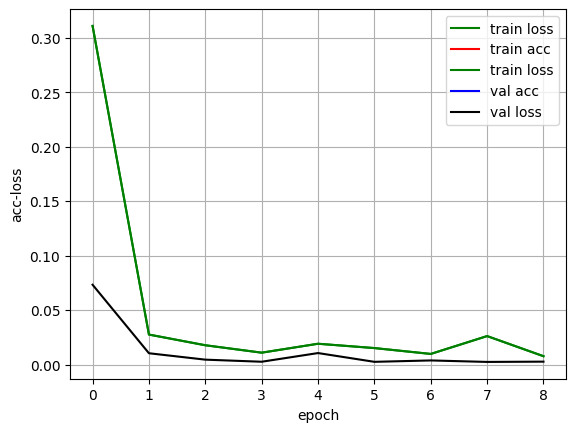

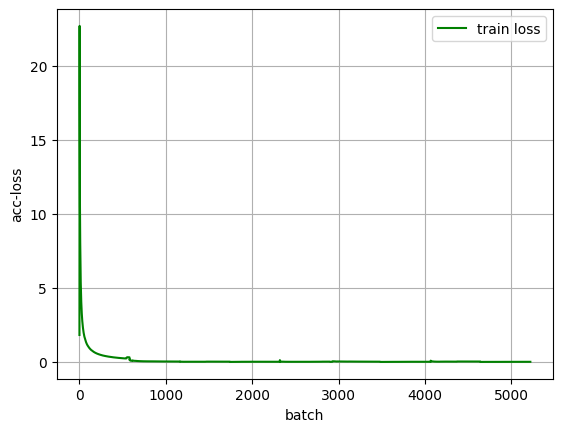

In [14]:
vgg16(num_class=5,epochs=20)	#tf36cnn
history_this.loss_plot('epoch')
history_this.loss_plot('batch')
plt.show()

Validation accuracy of VGG16: 100.0%

### Model 4: VGG19

In [12]:
def vgg19( num_class, epochs,savepath='./VGG19.h5',history=history_this,input_shape=INPUT_SIZE):
    model_fine_tune = VGG19(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in model_fine_tune.layers[:19]:	#the number of frozen layers for transfer learning, have tuned from 5-18
        layer.trainable = False
    for layer in model_fine_tune.layers[19:]:
        layer.trainable = True
    model = GlobalAveragePooling2D()(model_fine_tune.output)
    model=Dense(units=256,activation='relu')(model)
    model=Dropout(0.5)(model)
    model = Dense(num_class, activation='softmax')(model)
    model = Model(model_fine_tune.input, model, name='vgg')
    opt = keras.optimizers.Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=1e-08)	#tuned learning rate to be 0.001
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])	#set the loss function to be binary crossentropy
    #train model
    earlyStopping = kcallbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, verbose=1, mode='max')	#set early stop patience to save training time
    saveBestModel = kcallbacks.ModelCheckpoint(
        filepath=savepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max')
    hist = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        #use_multiprocessing=True,
        #workers=2,
        callbacks=[earlyStopping, saveBestModel, history],
    )


Epoch 1/20
580/580 [==============================] - ETA: 0s - loss: 0.1003 - accuracy: 0.9734
Epoch 1: val_accuracy improved from -inf to 0.99763, saving model to ./VGG19.h5
580/580 [==============================] - 121s 205ms/step - loss: 0.1003 - accuracy: 0.9734 - val_loss: 0.0078 - val_accuracy: 0.9976
Epoch 2/20
580/580 [==============================] - ETA: 0s - loss: 0.0163 - accuracy: 0.9963
Epoch 2: val_accuracy improved from 0.99763 to 0.99773, saving model to ./VGG19.h5
580/580 [==============================] - 122s 211ms/step - loss: 0.0163 - accuracy: 0.9963 - val_loss: 0.0075 - val_accuracy: 0.9977
Epoch 3/20
580/580 [==============================] - ETA: 0s - loss: 0.0122 - accuracy: 0.9970
Epoch 3: val_accuracy improved from 0.99773 to 0.99903, saving model to ./VGG19.h5
580/580 [==============================] - 123s 211ms/step - loss: 0.0122 - accuracy: 0.9970 - val_loss: 0.0077 - val_accuracy: 0.9990
Epoch 4/20
580/580 [==============================] - ETA: 0s

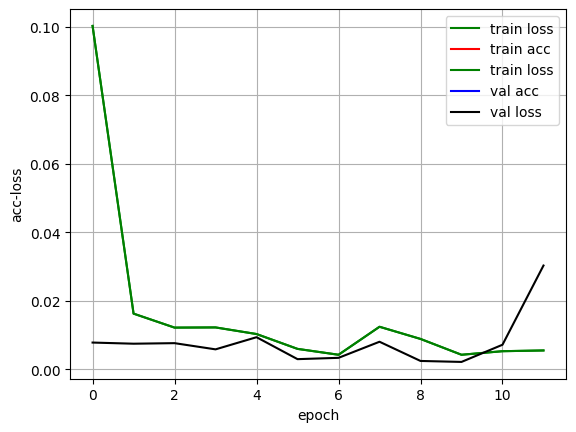

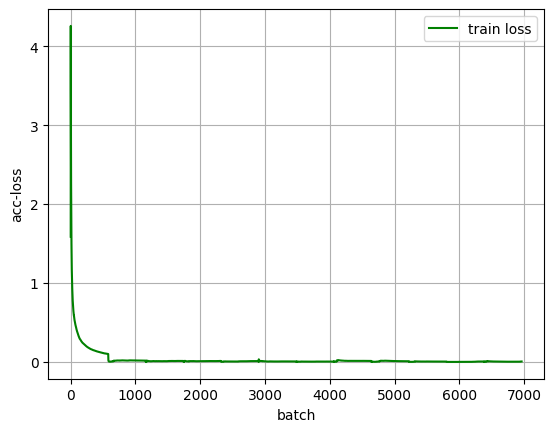

In [16]:
vgg19(num_class=5,epochs=20)	#binary classificaiton
history_this.loss_plot('epoch')
history_this.loss_plot('batch')
plt.show()

Validation accuracy of VGG19: 100.0%

### Model 5: ResNet

In [25]:
def resnet( num_class, epochs,savepath='./resnet.h5',history=history_this,input_shape=INPUT_SIZE):
    model_fine_tune = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in model_fine_tune.layers[:120]:	#the number of frozen layers for transfer learning, have tuned from 50-150
        layer.trainable = False
    for layer in model_fine_tune.layers[120:]:	#the number of trainable layers for transfer learning
        layer.trainable = True
    model = GlobalAveragePooling2D()(model_fine_tune.output)
    model=Dense(units=256,activation='relu')(model)
    model=Dropout(0.5)(model)
    model = Dense(num_class, activation='softmax')(model)
    model = Model(model_fine_tune.input, model, name='resnet')
    opt = keras.optimizers.Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=1e-08)	#tuned learning rate to be 0.001
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy']) #set the loss function to be binary crossentropy
    #train model
    earlyStopping = kcallbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, verbose=1, mode='max')	#set early stop patience to save training time
    saveBestModel = kcallbacks.ModelCheckpoint(
        filepath=savepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max')
    hist = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        #use_multiprocessing=True,
        callbacks=[earlyStopping, saveBestModel, history],
    )

Epoch 1/20
580/580 [==============================] - ETA: 0s - loss: 0.1298 - accuracy: 0.9611
Epoch 1: val_accuracy improved from -inf to 0.80382, saving model to ./resnet.h5
580/580 [==============================] - 201s 317ms/step - loss: 0.1298 - accuracy: 0.9611 - val_loss: 11.3620 - val_accuracy: 0.8038
Epoch 2/20
580/580 [==============================] - ETA: 0s - loss: 0.0368 - accuracy: 0.9892
Epoch 2: val_accuracy improved from 0.80382 to 0.85098, saving model to ./resnet.h5
580/580 [==============================] - 134s 231ms/step - loss: 0.0368 - accuracy: 0.9892 - val_loss: 2.8450 - val_accuracy: 0.8510
Epoch 3/20
580/580 [==============================] - ETA: 0s - loss: 0.0223 - accuracy: 0.9940
Epoch 3: val_accuracy did not improve from 0.85098
580/580 [==============================] - 129s 221ms/step - loss: 0.0223 - accuracy: 0.9940 - val_loss: 52.2326 - val_accuracy: 0.8038
Epoch 4/20
580/580 [==============================] - ETA: 0s - loss: 0.0179 - accuracy: 

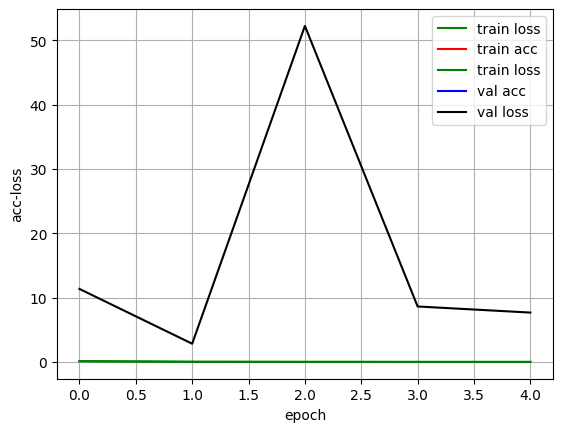

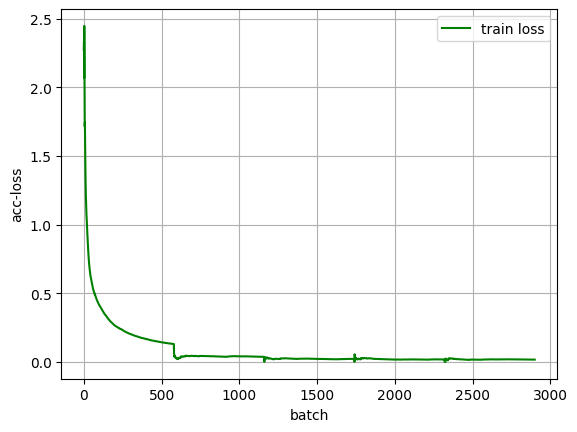

In [26]:
resnet(num_class=5,epochs=20)	#binary classificaiton
history_this.loss_plot('epoch')
history_this.loss_plot('batch')
plt.show()

Validation accuracy of Resnet: 98.652%

### Model 6: Inception

In [14]:
def inception( num_class, epochs,savepath='./inception.h5',history=history_this,input_shape=INPUT_SIZE):
    model_fine_tune = InceptionV3(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in model_fine_tune.layers[:148]:	#the number of frozen layers for transfer learning, have tuned from 50-150
        layer.trainable = False
    for layer in model_fine_tune.layers[148:]:	#the number of trainable layers for transfer learning
        layer.trainable = True
    model = GlobalAveragePooling2D()(model_fine_tune.output)
    model=Dense(units=256,activation='relu')(model)
    model=Dropout(0.5)(model)
    model = Dense(num_class, activation='softmax')(model)
    model = Model(model_fine_tune.input, model, name='resnet')
    opt = keras.optimizers.Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=1e-08)	#tuned learning rate to be 0.001
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy']) #set the loss function to be binary crossentropy
    #train model
    earlyStopping = kcallbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, verbose=1, mode='max')	#set early stop patience to save training time
    saveBestModel = kcallbacks.ModelCheckpoint(
        filepath=savepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max')
    hist = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        #use_multiprocessing=True,
        callbacks=[earlyStopping, saveBestModel, history],
    )

Epoch 1/20
580/580 [==============================] - ETA: 0s - loss: 0.0731 - accuracy: 0.9822
Epoch 1: val_accuracy improved from -inf to 0.99698, saving model to ./inception.h5
580/580 [==============================] - 142s 203ms/step - loss: 0.0731 - accuracy: 0.9822 - val_loss: 0.0225 - val_accuracy: 0.9970
Epoch 2/20


2026-05-20 22:18:26.283239: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38536448 bytes after encountering the first element of size 38536448 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


580/580 [==============================] - ETA: 0s - loss: 0.0179 - accuracy: 0.9960
Epoch 2: val_accuracy improved from 0.99698 to 0.99860, saving model to ./inception.h5
580/580 [==============================] - 114s 196ms/step - loss: 0.0179 - accuracy: 0.9960 - val_loss: 0.0045 - val_accuracy: 0.9986
Epoch 3/20
580/580 [==============================] - ETA: 0s - loss: 0.0109 - accuracy: 0.9979
Epoch 3: val_accuracy did not improve from 0.99860
580/580 [==============================] - 108s 185ms/step - loss: 0.0109 - accuracy: 0.9979 - val_loss: 0.0044 - val_accuracy: 0.9983
Epoch 4/20
580/580 [==============================] - ETA: 0s - loss: 0.0078 - accuracy: 0.9980
Epoch 4: val_accuracy did not improve from 0.99860
580/580 [==============================] - 104s 178ms/step - loss: 0.0078 - accuracy: 0.9980 - val_loss: 0.0039 - val_accuracy: 0.9985
Epoch 5/20
580/580 [==============================] - ETA: 0s - loss: 0.0051 - accuracy: 0.9984
Epoch 5: val_accuracy did not imp

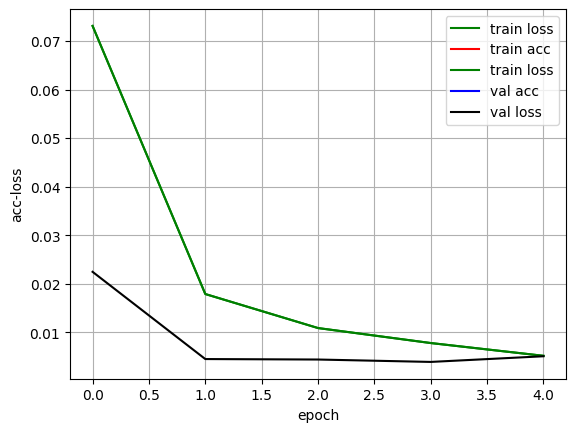

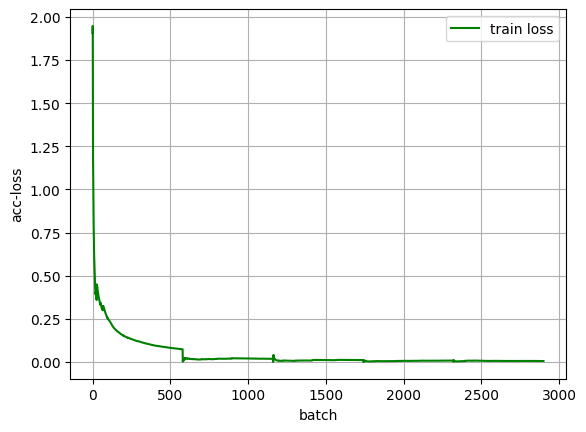

In [20]:
inception(num_class=5,epochs=20)	#binary classificaiton
history_this.loss_plot('epoch')
history_this.loss_plot('batch')
plt.show()

Validation accuracy of Inception: 100.0%

### Model 7: InceptionResnet

In [15]:
def inceptionresnet( num_class, epochs,savepath='./inceptionresnet.h5',history=history_this,input_shape=INPUT_SIZE):
    model_fine_tune = InceptionResNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in model_fine_tune.layers[:522]:	#the number of frozen layers for transfer learning, have tuned from 400-550
        layer.trainable = False
    for layer in model_fine_tune.layers[522:]:	#the number of trainable layers for transfer learning
        layer.trainable = True
    model = GlobalAveragePooling2D()(model_fine_tune.output)
    model=Dense(units=256,activation='relu')(model)
    model=Dropout(0.5)(model)
    model = Dense(num_class, activation='softmax')(model)
    model = Model(model_fine_tune.input, model, name='resnet')
    opt = keras.optimizers.Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=1e-08)	#tuned learning rate to be 0.001
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy']) #set the loss function to be binary crossentropy
    #train model
    earlyStopping = kcallbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, verbose=1, mode='max')	#set early stop patience to save training time
    saveBestModel = kcallbacks.ModelCheckpoint(
        filepath=savepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max')
    hist = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        #use_multiprocessing=True,
        callbacks=[earlyStopping, saveBestModel, history],
    )

219055592/219055592 [==============================] - 11s 0us/step
Epoch 1/20
580/580 [==============================] - ETA: 0s - loss: 0.1089 - accuracy: 0.9728
Epoch 1: val_accuracy improved from -inf to 0.98608, saving model to ./inceptionresnet.h5
580/580 [==============================] - 219s 318ms/step - loss: 0.1089 - accuracy: 0.9728 - val_loss: 0.0575 - val_accuracy: 0.9861
Epoch 2/20


2026-05-20 22:30:06.369962: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38536448 bytes after encountering the first element of size 38536448 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


580/580 [==============================] - ETA: 0s - loss: 0.0404 - accuracy: 0.9901
Epoch 2: val_accuracy improved from 0.98608 to 0.99633, saving model to ./inceptionresnet.h5
580/580 [==============================] - 192s 329ms/step - loss: 0.0404 - accuracy: 0.9901 - val_loss: 0.0150 - val_accuracy: 0.9963
Epoch 3/20
580/580 [==============================] - ETA: 0s - loss: 0.0551 - accuracy: 0.9859
Epoch 3: val_accuracy did not improve from 0.99633
580/580 [==============================] - 170s 292ms/step - loss: 0.0551 - accuracy: 0.9859 - val_loss: 0.0293 - val_accuracy: 0.9905
Epoch 4/20
580/580 [==============================] - ETA: 0s - loss: 0.0254 - accuracy: 0.9936
Epoch 4: val_accuracy did not improve from 0.99633
580/580 [==============================] - 170s 293ms/step - loss: 0.0254 - accuracy: 0.9936 - val_loss: 0.0374 - val_accuracy: 0.9887
Epoch 5/20
580/580 [==============================] - ETA: 0s - loss: 0.0203 - accuracy: 0.9960
Epoch 5: val_accuracy did n

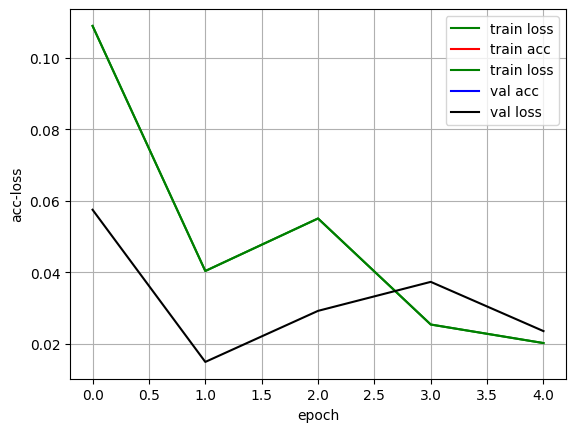

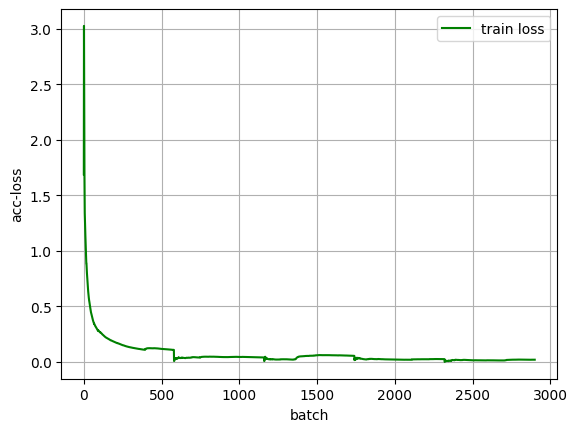

In [22]:
inceptionresnet(num_class=5,epochs=20)	# 5-class classificaiton
history_this.loss_plot('epoch')
history_this.loss_plot('batch')
plt.show()

Validation accuracy of InceptionResnet: 99.993%

# Hyperparameter Optimization
Use VGG16 as an example.  

Tuned hyperparameters of CNN:
1. The number of frozen layers
2. The number of epochs
3. Early stop patience
4. Learning rate
5. Dropout rate

Hyperparameter optimization methods:
1. Random search
2. Bayesian optimization - Tree Parzen Estimator(BO-TPE)

In [17]:
def vgg16( num_class,epochs=20,frozen=15,learning_rate=0.003,patience=3, dropout_rate=0.5,verbose=2, savepath='./VGG16.h5',history=history_this,input_shape=INPUT_SIZE):
    model_fine_tune = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    for layer in model_fine_tune.layers[:frozen]:	#the number of frozen layers for transfer learning, have tuned from 5-18
        layer.trainable = False
    for layer in model_fine_tune.layers[frozen:]:
        layer.trainable = True
    model = GlobalAveragePooling2D()(model_fine_tune.output)
    model=Dense(units=256,activation='relu')(model)
    model=Dropout(dropout_rate)(model)
    model = Dense(num_class, activation='softmax')(model)
    model = Model(model_fine_tune.input, model, name='vgg')
    opt = keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-08)	#tuned learning rate to be 0.001
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])	#set the loss function to be binary crossentropy
    #train model
    earlyStopping = kcallbacks.EarlyStopping(
        monitor='val_accuracy', patience=patience, verbose=verbose, mode='max')	#set early stop patience to save training time
    saveBestModel = kcallbacks.ModelCheckpoint(
        filepath=savepath,
        monitor='val_accuracy',
        verbose=verbose,
        save_best_only=True,
        mode='max')
    hist = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        #use_multiprocessing=True,
        #workers=2,
        callbacks=[earlyStopping, saveBestModel, history],
        verbose = verbose
    )
    return hist


In [18]:
def prediction(vgg_model):
#read images from validation folder
    rootdir = '/fast_dataset/test_224'
    test_laels = []
    test_images=[]
    for subdir, dirs, files in os.walk(rootdir):
        for file in files:
            if not (file.endswith(".jpeg"))|(file.endswith(".jpg"))|(file.endswith(".png")):
                continue
            test_laels.append(subdir.split('/')[-1])
            test_images.append(os.path.join(subdir, file))

    predict=[]
    length=len(test_images)
    label=validation_generator.class_indices
    label={v: k for k, v in label.items()}
    for i in range(length):
        inputimg=test_images[i]
        test_batch=[]
        thisimg=np.array(Image.open(inputimg))/255 #read all the images in validation set
        #print(thisimg)
        test_shape=(1,)+thisimg.shape
        thisimg=thisimg.reshape(test_shape)
        vgg_model_batch=vgg_model.predict(thisimg, verbose=0) #use master model to process the input image
        #generate result by model 1
        prob=vgg_model_batch[0,np.argmax(vgg_model_batch,axis=1)[0]]
        res=label[np.argmax(vgg_model_batch,axis=1)[0]]
        predict.append(res)
    acc=accuracy_score(test_laels,predict)
    return acc

In [19]:
#!pip install hyperopt

In [20]:
#define the objective function to be optimized
import time
from hyperopt import hp, fmin, tpe, rand, STATUS_OK, Trials
import matplotlib.pyplot as plt
import statistics

def objective(params):

    params = {
        'frozen': int(params['frozen']),
        'epochs': int(params['epochs']),
        'patience': int(params['patience']),
        'learning_rate': abs(float(params['learning_rate'])),
        'dropout_rate': abs(float(params['dropout_rate'])),
    }
    frozen=params['frozen']
    epochs=params['epochs']
    patience=params['patience']
    learning_rate=params['learning_rate']
    dropout_rate=params['dropout_rate']

    vgg16(num_class=5, frozen=frozen,epochs=epochs,patience=patience, learning_rate=learning_rate, dropout_rate=dropout_rate)

    acc=prediction(vgg_model=load_model('./VGG16.h5'))

    print('accuracy:%s'%acc)
    return {'loss': -acc, 'status': STATUS_OK }


In [21]:
#Hyperparameter optimization by Bayesian optimization - Tree Parzen Estimator
space = {
    'frozen': hp.quniform('frozen', 15, 18, 1),
    'epochs': hp.quniform('epochs', 5, 21, 5),
    'patience': hp.quniform('patience', 2, 4, 1),
    'learning_rate': hp.quniform('learning_rate', 0.001, 0.006, 0.001),
    'dropout_rate': hp.quniform('dropout_rate', 0.3, 0.6, 0.1),
}

t1=time.time()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=10)
print("Hyperopt estimated optimum {}".format(best))
t2=time.time()
print("Time: "+str(t2-t1))

  0%|                                                                            | 0/10 [00:00<?, ?trial/s, best loss=?]

2026-05-21 02:52:47.412331: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 02:52:47.412415: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 02:52:47.412448: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 02:52:47.794713: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 02:52:47.794772: I external/local_xla/xla/stream_executor

Epoch 1/20                                                                                                              

  0%|                                                                            | 0/10 [00:01<?, ?trial/s, best loss=?]

2026-05-21 02:52:49.831761: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-05-21 02:52:59.130293: I external/local_xla/xla/service/service.cc:168] XLA service 0x7b2bf9652560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-21 02:52:59.130347: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-05-21 02:52:59.156388: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779331979.280413   50982 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


                                                                                                                        
Epoch 1: val_accuracy improved from -inf to 0.99072, saving model to ./VGG16.h5

  0%|                                                                            | 0/10 [02:07<?, ?trial/s, best loss=?]

...

580/580 - 123s - loss: 0.0975 - accuracy: 0.9690 - val_loss: 0.0244 - val_accuracy: 0.9927 - 123s/epoch - 212ms/step    

Epoch 2/15                                                                                                              

                                                                                                                        
Epoch 2: val_accuracy improved from 0.99266 to 0.99299, saving model to ./VGG16.h5

580/580 - 121s - loss: 0.0300 - accuracy: 0.9905 - val_loss: 0.0216 - val_accuracy: 0.9930 - 121s/epoch - 209ms/step    

Epoch 3/15                                                                                                              

                                                                                                                        
Epoch 3: val_accuracy improved from 0.99299 to 0.99514, saving model to ./VGG16.h5

580/580 - 121s - loss: 0.0236 - accuracy: 0.9931 - val_loss: 0.0147 - val_accuracy: 0.9951 - 121s/epoc

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



580/580 - 101s - loss: 0.0764 - accuracy: 0.9819 - val_loss: 0.0109 - val_accuracy: 0.9962 - 101s/epoch - 175ms/step    

Epoch 2/20                                                                                                              

                                                                                                                        
Epoch 2: val_accuracy improved from 0.99622 to 0.99817, saving model to ./VGG16.h5

580/580 - 100s - loss: 0.0091 - accuracy: 0.9978 - val_loss: 0.0051 - val_accuracy: 0.9982 - 100s/epoch - 172ms/step    

Epoch 3/20                                                                                                              

                                                                                                                        
Epoch 3: val_accuracy did not improve from 0.99817

580/580 - 98s - loss: 0.0068 - accuracy: 0.9983 - val_loss: 0.0104 - val_accuracy: 0.9964 - 98s/epoch - 170ms/step      

Epoch 4/20  

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



580/580 - 104s - loss: 0.1148 - accuracy: 0.9695 - val_loss: 0.0125 - val_accuracy: 0.9964 - 104s/epoch - 180ms/step    

Epoch 2/20                                                                                                              

                                                                                                                        
Epoch 2: val_accuracy improved from 0.99644 to 0.99741, saving model to ./VGG16.h5

580/580 - 103s - loss: 0.0150 - accuracy: 0.9959 - val_loss: 0.0083 - val_accuracy: 0.9974 - 103s/epoch - 177ms/step    

Epoch 3/20                                                                                                              

                                                                                                                        
Epoch 3: val_accuracy improved from 0.99741 to 0.99817, saving model to ./VGG16.h5

580/580 - 103s - loss: 0.0123 - accuracy: 0.9966 - val_loss: 0.0048 - val_accuracy: 0.9982 - 103s/epoc

In [22]:
#Hyperparameter optimization by Random search
space = {
    'frozen': hp.quniform('frozen', 15, 18, 1),
    'epochs': hp.quniform('epochs', 5, 21, 5),
    'patience': hp.quniform('patience', 2, 4, 1),
    'learning_rate': hp.quniform('learning_rate', 0.001, 0.006, 0.001),
    'dropout_rate': hp.quniform('dropout_rate', 0.3, 0.6, 0.1),
}

t1=time.time()
best = fmin(fn=objective,
            space=space,
            algo=rand.suggest,
            max_evals=10)
print("Hyperopt estimated optimum {}".format(best))
t2=time.time()
print("Time: "+str(t2-t1))

Epoch 1/15                                                                                                              

                                                                                                                        
Epoch 1: val_accuracy improved from -inf to 0.99245, saving model to ./VGG16.h5

  0%|                                                                            | 0/10 [01:43<?, ?trial/s, best loss=?]

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



580/580 - 105s - loss: 0.2941 - accuracy: 0.9581 - val_loss: 0.0172 - val_accuracy: 0.9924 - 105s/epoch - 180ms/step    

Epoch 2/15                                                                                                              

                                                                                                                        
Epoch 2: val_accuracy improved from 0.99245 to 0.99698, saving model to ./VGG16.h5

580/580 - 103s - loss: 0.0256 - accuracy: 0.9940 - val_loss: 0.0136 - val_accuracy: 0.9970 - 103s/epoch - 178ms/step    

Epoch 3/15                                                                                                              

                                                                                                                        
Epoch 3: val_accuracy improved from 0.99698 to 0.99773, saving model to ./VGG16.h5

580/580 - 103s - loss: 0.0228 - accuracy: 0.9952 - val_loss: 0.0068 - val_accuracy: 0.9977 - 103s/epoc

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



580/580 - 104s - loss: 0.1044 - accuracy: 0.9701 - val_loss: 0.0634 - val_accuracy: 0.9889 - 104s/epoch - 180ms/step    

Epoch 2/5                                                                                                               

                                                                                                                        
Epoch 2: val_accuracy improved from 0.98889 to 0.99547, saving model to ./VGG16.h5

580/580 - 103s - loss: 0.0183 - accuracy: 0.9957 - val_loss: 0.0173 - val_accuracy: 0.9955 - 103s/epoch - 177ms/step    

Epoch 3/5                                                                                                               

                                                                                                                        
Epoch 3: val_accuracy improved from 0.99547 to 0.99892, saving model to ./VGG16.h5

580/580 - 103s - loss: 0.0068 - accuracy: 0.9983 - val_loss: 0.0029 - val_accuracy: 0.9989 - 103s/epoc

...

580/580 - 101s - loss: 0.0509 - accuracy: 0.9862 - val_loss: 0.0072 - val_accuracy: 0.9982 - 101s/epoch - 175ms/step    

Epoch 2/15                                                                                                              

                                                                                                                        
Epoch 2: val_accuracy did not improve from 0.99817

580/580 - 97s - loss: 0.0088 - accuracy: 0.9977 - val_loss: 0.0119 - val_accuracy: 0.9963 - 97s/epoch - 168ms/step      

Epoch 3/15                                                                                                              

                                                                                                                        
Epoch 3: val_accuracy did not improve from 0.99817

580/580 - 99s - loss: 0.0076 - accuracy: 0.9981 - val_loss: 0.0055 - val_accuracy: 0.9982 - 99s/epoch - 171ms/step      

Epoch 4/15                                  

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



580/580 - 122s - loss: 0.1075 - accuracy: 0.9651 - val_loss: 0.0261 - val_accuracy: 0.9915 - 122s/epoch - 211ms/step    

Epoch 2/10                                                                                                              

                                                                                                                        
Epoch 2: val_accuracy did not improve from 0.99148

580/580 - 120s - loss: 0.0356 - accuracy: 0.9883 - val_loss: 0.0291 - val_accuracy: 0.9907 - 120s/epoch - 207ms/step    

Epoch 3/10                                                                                                              

                                                                                                                        
Epoch 3: val_accuracy improved from 0.99148 to 0.99536, saving model to ./VGG16.h5

580/580 - 121s - loss: 0.0312 - accuracy: 0.9896 - val_loss: 0.0145 - val_accuracy: 0.9954 - 121s/epoch - 209ms/step    

Epoch 4/10  

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



580/580 - 104s - loss: 0.1260 - accuracy: 0.9612 - val_loss: 0.0175 - val_accuracy: 0.9954 - 104s/epoch - 180ms/step    

Epoch 2/20                                                                                                              

                                                                                                                        
Epoch 2: val_accuracy did not improve from 0.99536

580/580 - 101s - loss: 0.0231 - accuracy: 0.9944 - val_loss: 0.0302 - val_accuracy: 0.9914 - 101s/epoch - 174ms/step    

Epoch 3/20                                                                                                              

                                                                                                                        
Epoch 3: val_accuracy improved from 0.99536 to 0.99860, saving model to ./VGG16.h5

580/580 - 103s - loss: 0.0142 - accuracy: 0.9966 - val_loss: 0.0045 - val_accuracy: 0.9986 - 103s/epoch - 178ms/step    

Epoch 4/20  

In [24]:
# Retrain the model by using the best hyperparameter values to obtain the best model
vgg16(
    num_class=5, 
    frozen=16, 
    epochs=5,         
    patience=2,       
    learning_rate=0.002, 
    dropout_rate=0.5, 
    verbose=1         
)

Epoch 1/5
580/580 [==============================] - ETA: 0s - loss: 0.1156 - accuracy: 0.9696
Epoch 1: val_accuracy improved from -inf to 0.99752, saving model to ./VGG16.h5
580/580 [==============================] - 176s 300ms/step - loss: 0.1156 - accuracy: 0.9696 - val_loss: 0.0094 - val_accuracy: 0.9975
Epoch 2/5
580/580 [==============================] - ETA: 0s - loss: 0.0168 - accuracy: 0.9961
Epoch 2: val_accuracy improved from 0.99752 to 0.99795, saving model to ./VGG16.h5
580/580 [==============================] - 114s 196ms/step - loss: 0.0168 - accuracy: 0.9961 - val_loss: 0.0075 - val_accuracy: 0.9979
Epoch 3/5
580/580 [==============================] - ETA: 0s - loss: 0.0153 - accuracy: 0.9958
Epoch 3: val_accuracy improved from 0.99795 to 0.99817, saving model to ./VGG16.h5
580/580 [==============================] - 110s 189ms/step - loss: 0.0153 - accuracy: 0.9958 - val_loss: 0.0047 - val_accuracy: 0.9982
Epoch 4/5
580/580 [==============================] - ETA: 0s - l